In [1]:
'''
Initial Exploration of the Data

Summary

misc ideas / to do
make my own target of severity / interest

if vehicle stopped or not and analysis

thinking maybe basic graphs and then for the website a dropdown of key things or scrollable and the user can select which type of incidents to have at the top

Backlog
* some of the columns from the prior data may be matchable to the later data to improve the number of rows


'''

'\nInitial Exploration of the Data\n\nSummary\n\nmisc ideas / to do\nmake my own target of severity / interest\n\nif vehicle stopped or not and analysis\n\nthinking maybe basic graphs and then for the website a dropdown of key things or scrollable and the user can select which type of incidents to have at the top\n\nBacklog\n* some of the columns from the prior data may be matchable to the later data to improve the number of rows\n\n\n'

In [2]:
import pandas as pd
import numpy as np

import sys
sys.path.append('..')

import eda_utils_sgo
import eda_utils_nlp


pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 300)

In [3]:
%load_ext autoreload
%autoreload 2

## Load Data

In [4]:
from pathlib import Path
repo_root = Path.cwd().parents[1]  # eda/ADS_to_2026_03_16 -> repo root
data_dir = repo_root / 'data' / 'nhtsa'
paths = [
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv',
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_2025_06_16_to_2026_03_16.csv',
]

In [5]:
ads_df = eda_utils_sgo.load_and_concat_csvs(paths)

Only in SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv:
  ADAS/ADS Hardware Version
  ADAS/ADS Hardware Version - Unk
  ADAS/ADS Hardware Version CBI
  ADAS/ADS Software Version
  ADAS/ADS Software Version - Unk
  ADAS/ADS Software Version CBI
  ADAS/ADS System Version
  ADAS/ADS System Version - Unk
  ADAS/ADS System Version CBI
  ADS Equipped?
  CP Any Air Bags Deployed?
  CP Was Vehicle Towed?
  Federal Reg. Exemption - No
  Federal Reg. Exemption - Unk
  Federal Regulatory Exemption?
  Inv. Officer Email - Unknown
  Inv. Officer Name - Unknown
  Inv. Officer Phone - Unknown
  Investigating Officer Email
  Investigating Officer Name
  Investigating Officer Phone
  Law Enforcement Investigating?
  Lighting
  Mileage
  Mileage - Unknown
  Notice Received Date
  Other Federal Reg. Exemption
  Other Reporting Entities?
  Other Reporting Entities? - NA
  Other Reporting Entities? - Unk
  Posted Speed Limit (MPH)
  Posted Speed Limit - Unknown
  Property Damage?
  Rep Ent Or Mfr Inves

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
3115     0.0
3116     0.0
3117    10.0
3118     0.0
3119    31.0
Name: SV Precrash Speed (MPH), Length: 3120, dtype: float64

### Notes
* Different dtypes is fine for the mix
* Many columns are different not sure if there are equivalent ones in one file and not the other

In [6]:
early_df = pd.read_csv(paths[0])
print(early_df.shape)

(2295, 137)


In [7]:
later_df = pd.read_csv(paths[1])
print(later_df.shape)

(825, 116)


In [18]:
early_df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 2295 entries, 0 to 2294
Data columns (total 137 columns):
 #    Column                           Dtype  
---   ------                           -----  
 0    Report ID                        str    
 1    Report Version                   int64  
 2    Reporting Entity                 str    
 3    Report Type                      str    
 4    Report Month                     float64
 5    Report Year                      float64
 6    Report Submission Date           str    
 7    VIN                              str    
 8    VIN - Unknown                    str    
 9    Serial Number                    str    
 10   Make                             str    
 11   Model                            str    
 12   Model - Unknown                  str    
 13   Model Year                       float64
 14   Model Year - Unknown             str    
 15   Same Vehicle ID                  str    
 16   Mileage                          float64
 17   Mile

In [19]:
later_df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 116 columns):
 #    Column                            Dtype  
---   ------                            -----  
 0    Report ID                         str    
 1    Report Version                    int64  
 2    Reporting Entity                  str    
 3    Report Type                       str    
 4    Report Month                      float64
 5    Report Year                       float64
 6    Report Submission Date            str    
 7    VIN                               str    
 8    VIN Decoded                       str    
 9    Serial Number                     str    
 10   Make                              str    
 11   Make - Unknown                    str    
 12   Model                             str    
 13   Model - Unknown                   str    
 14   Model Year                        int64  
 15   Model Year - Unknown              str    
 16   Same Vehicle ID                   s

## Data Basic

In [20]:
print(ads_df.shape)

(3120, 164)


In [21]:
ads_df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 3120 entries, 0 to 3119
Data columns (total 164 columns):
 #    Column                            Dtype  
---   ------                            -----  
 0    Report ID                         str    
 1    Report Version                    int64  
 2    Reporting Entity                  str    
 3    Report Type                       str    
 4    Report Month                      float64
 5    Report Year                       float64
 6    Report Submission Date            str    
 7    VIN                               str    
 8    VIN - Unknown                     str    
 9    Serial Number                     str    
 10   Make                              str    
 11   Model                             str    
 12   Model - Unknown                   str    
 13   Model Year                        float64
 14   Model Year - Unknown              str    
 15   Same Vehicle ID                   str    
 16   Mileage                          

### NA Check

In [24]:
ads_df.isna().mean().reset_index().sort_values(0,ascending=False)

,index,0
32,Other Federal Reg. Exemption,0.998077
80,Weather - Other Text,0.998077
31,Federal Regulatory Exemption?,0.991667
48,Source - Other Text,0.988141
131,Investigating Officer Email,0.985256
129,Investigating Officer Phone,0.955449
28,Other Reporting Entities?,0.851923
127,Investigating Officer Name,0.844551
9,Serial Number,0.822115
124,Investigating Agency,0.752564


In [25]:
later_df.isna().mean().reset_index().sort_values(0,ascending=False)

,index,0
17,Driver / Operator Type,0.844848
110,Investigating Agency,0.750303
5,Report Year,0.534545
4,Report Month,0.534545
9,Serial Number,0.379394
49,Zip Code,0.244848
44,Address,0.244848
81,CP Contact Area - Right,0.076364
82,CP Contact Area - Front Right,0.076364
84,CP Contact Area - Unknown,0.076364


### Notes
* many of the NA from the later data and earlier are due to different column names / data being collected

## Value Counts

In [29]:
for cn in ads_df.columns:
    display(ads_df[cn].value_counts(dropna=False, normalize=True).head(50))

Report ID
28349-5694     0.001603
540-6400       0.001282
30412-6395     0.001282
30531-4719     0.001282
30270-8979     0.000962
30270-8940     0.000962
540-4019       0.000962
540-3753       0.000962
30412-3978     0.000962
30412-3748     0.000962
30270-8444     0.000962
30270-7157     0.000962
30270-7318     0.000962
540-6148       0.000962
30412-6144     0.000962
669-5206       0.000962
540-5425       0.000962
30412-5422     0.000962
30610-3703     0.000962
540-5102       0.000962
30531-4721     0.000962
540-4541       0.000962
30412-2173     0.000962
30711-1759     0.000962
669-1762       0.000962
30531-1200     0.000962
30531-1191     0.000962
30531-33       0.000962
502-1163       0.000962
30531-6        0.000962
30531-2        0.000962
31101-13612    0.000962
13781-11375    0.000962
30270-11016    0.000641
30270-11014    0.000641
30610-10473    0.000641
30610-10294    0.000641
30610-10999    0.000641
30270-10977    0.000641
30270-10596    0.000641
30270-10892    0.000641
30270-

Report Version
1    0.867949
2    0.119872
3    0.010577
4    0.001282
5    0.000321
Name: proportion, dtype: float64

Reporting Entity
Waymo LLC                                   0.633974
Cruise LLC                                  0.066346
General Motors, LLC                         0.064423
Transdev Alternative Services               0.060256
Zoox, Inc.                                  0.050000
Avride Inc.                                 0.014423
May Mobility                                0.013141
Motional                                    0.008333
Ford Motor Company                          0.008333
Argo AI                                     0.008333
PACCAR Incorporated                         0.007051
Aurora Operations, Inc.                     0.006731
Hyundai Motor America                       0.006410
Tesla, Inc.                                 0.005769
Beep, Inc.                                  0.004808
WeRide Corp                                 0.003846
Nuro                                        0.003846
Kodiak Robotics                             0.003205
Pony.ai                      

Report Type
Monthly                               0.523397
5-Day                                 0.244872
1-Day                                 0.098718
10-Day Update                         0.084295
Update                                0.047756
No New or Updated Incident Reports    0.000962
Name: proportion, dtype: float64

Report Month
NaN     0.467949
12.0    0.055769
8.0     0.051923
9.0     0.049679
10.0    0.045833
2.0     0.045513
11.0    0.045192
5.0     0.042308
1.0     0.041026
3.0     0.040705
4.0     0.039423
7.0     0.039103
6.0     0.035577
Name: proportion, dtype: float64

...

Weather - Structure-Indoor
NaN    0.735577
       0.263782
Y      0.000641
Name: proportion, dtype: float64

Weather - Unk - See Narrative
NaN    0.735577
       0.264423
Name: proportion, dtype: float64

Any Air Bags Deployed?
NaN                                           0.735577
No Subject Vehicle, No Crash Partner          0.240705
Yes Crash Partner, No Subject Vehicle         0.009295
No Subject Vehicle, Unknown Crash Partner     0.007051
Yes Subject Vehicle, Yes Crash Partner        0.004167
Not Applicable                                0.001603
Yes Subject Vehicle, No Crash Partner         0.000962
Yes Subject Vehicle, Unknown Crash Partner    0.000321
No Crash Partner, Unknown Subject Vehicle     0.000321
Name: proportion, dtype: float64

Was Any Vehicle Towed?
NaN                                           0.735577
No Subject Vehicle, No Crash Partner          0.126282
Yes Subject Vehicle, No Crash Partner         0.108333
Yes Subject Vehicle, Yes Crash Partner        0.016026
Yes Subject Vehicle, Unknown Crash Partner    0.005449
Yes Crash Partner, No Subject Vehicle         0.004487
No Subject Vehicle, Unknown Crash Partner     0.003846
Name: proportion, dtype: float64

Were All Passengers Belted?
NaN                                             0.735577
Subject Vehicle - All Belted                    0.131731
Subject Vehicle - No Passenger In Vehicle       0.109615
Subject Vehicle - Not Belted - see Narrative    0.021795
Unknown                                         0.001282
Name: proportion, dtype: float64

### Notes
* rough, see below. Many ideas and future things to potentially do
* will work into a to do list and prioritize

In [ ]:
'''
Value counts notes
table by entity and by time
Make and model can be consolidated: some duplicate options
can add things like ODD and definitions
maybe can do somethign with mileage. would ideally need mileage of all the vehicles to understand if any affect
Driver / Operator Type: probalby need to filter by something ueful
ADAS/ADS System Version/ADAS/ADS Hardware Version/ADAS/ADS Software Version: see who the redatcted belongs to
State or Local Permit: can likely be cleaned up, many dupes for near things, even a simple string treatment

Operating Entity: can be cleaned up, paroticularly if the gourpoing
	to do: figure which entity to group on

WHich source the comnplaint came from by entity could be worht following up on
Incident Date: by month count could be a simple chart
Incident time: do a chart / diagram of this to see if anyhing interesting
	maybe by night and dark as well
same incident id: see how many duplicates

ug location data of lat, long, address not htere. maybe use the Waymo and company data if stilla vailable

City and state could be some simple plots. see if can AI code something more dynamic for the front end too

could do a one pager of incident main details
	city, state, roadway type, service, time, date, Roadway Description, weather, crash with, highest injury, property damage, CP/SV Pre-Crash Movement, air bags deployed, vehicle towed, CP/SV contact area, SV passengers or not, precrash speed, law enforcement investigating
		maybe not in data anymore: speed limit, posted speed limit 
	stretch (not in data but can be gotten): night/day, temperature
	maybe filter by the data as well

potential target
	highest injury
	SV Pre-Crash Movement
	property damage
	air bag deployed
	was towed
	pre crash speed
	law enforcement investigating
	within ODD

misc idea: for redacted can do something dumb / silly where LLM reconstruct the text in a serious or jokey way based on the other data

combine the two contact area and speeds to get a sense of incident
	maybe a simple animation with the narrative

data availability: maybe quick summary
	maybe a stretch thing of where to get more (ie if a plicy report is available)
		investigating agency too

narrative data ideas
	ontology of narrative
	classification and attributes
	who classifies it and how much and why

investigating agency can be cleaned up to consolidate duplicates

legacy features that are similar but different between versions that could be combined / treated
	weather and roadway and air bags deployed, vehicle towed, passenger belted

'''

## Describe

In [27]:
ads_df.describe().apply(lambda x: x.apply('{:.3f}'.format))

,Report Version,Report Month,Report Year,Model Year,Mileage,Posted Speed Limit (MPH),SV Precrash Speed (MPH)
count,3120.000,1660.000,1660.000,3105.000,2241.000,2255.000,3083.000
mean,1.146,6.762,2023.916,2022.465,43947.894,29.313,6.892
std,0.397,3.517,1.288,1.961,70890.591,11.696,12.922
min,1.000,1.000,2021.000,2016.000,0.000,0.000,0.000
25%,1.000,4.000,2023.000,2021.000,8917.000,25.000,0.000
50%,1.000,7.000,2024.000,2023.000,23878.000,25.000,0.000
75%,1.000,10.000,2025.000,2024.000,55661.000,35.000,9.000
max,5.000,12.000,2026.000,2026.000,1685445.000,75.000,74.000


## Basic NLP

In [ ]:
# from eda_utils_nlp import describe_text_lengths, top_ngrams, top_tfidf

# describe_text_lengths(df['Narrative'])
# top_ngrams(df['Narrative'], n=2, top_k=20)
# top_tfidf(df['Narrative'], n=2, top_k=20)


In [8]:
ads_df['Narrative'].value_counts(dropna=False, normalize=True)

Narrative
[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [10]:
eda_utils_nlp.describe_text_lengths(ads_df['Narrative'])

Character length:
count    3118.000000
mean      910.050032
std       309.999790
min        46.000000
25%       766.000000
50%       909.000000
75%      1031.750000
max      3454.000000
Name: Narrative, dtype: float64

Word length:
count    3118.000000
mean      155.670943
std        52.758092
min         6.000000
25%       132.000000
50%       153.000000
75%       179.000000
max       552.000000
Name: Narrative, dtype: float64


,char_len,word_len
0,869,155
1,823,147
2,685,122
3,885,160
4,876,156
...,...,...
3115,1458,251
3116,809,143
3117,693,121
3118,612,101


In [11]:
eda_utils_nlp.top_ngrams(ads_df['Narrative'], n=2, top_k=20)

,ngram,count
0,waymo av,13703
1,xxx waymo,2684
2,passenger car,2634
3,autonomous mode,2608
4,autonomous vehicle,2466
5,av operating,2353
6,order 2021,2337
7,standing general,2337
8,2021 01,2336
9,general order,2335


In [15]:
for x in [1, 2, 3, 5, 10]:
    with pd.option_context('display.max_colwidth', 200):
        display(eda_utils_nlp.top_ngrams(ads_df['Narrative'], n=x, top_k=20))

,ngram,count
0,waymo,20491
1,av,15655
2,xxx,13052
3,vehicle,6351
4,autonomous,5161
5,reporting,4488
6,passenger,4467
7,lane,3214
8,mode,2996
9,information,2972


,ngram,count
0,waymo av,13703
1,xxx waymo,2684
2,passenger car,2634
3,autonomous mode,2608
4,autonomous vehicle,2466
5,av operating,2353
6,order 2021,2337
7,standing general,2337
8,2021 01,2336
9,general order,2335


,ngram,count
0,xxx waymo av,2659
1,general order 2021,2335
2,standing general order,2335
3,order 2021 01,2334
4,vehicle waymo av,2195
5,waymo autonomous vehicle,2148
6,autonomous vehicle waymo,2142
7,waymo av operating,2133
8,request standing general,2121
9,reporting crash request,2112


,ngram,count
0,standing general order 2021 01,2332
1,waymo autonomous vehicle waymo av,2139
2,request standing general order 2021,2119
3,autonomous vehicle waymo av operating,2114
4,crash request standing general order,2104
5,reporting crash request standing general,2100
6,supplement correct reporting additional information,2090
7,correct reporting additional information available,2088
8,level ads engaged autonomous mode,1953
9,waymo reporting crash request standing,1950


,ngram,count
0,damage waymo reporting crash request standing general order 2021 01,1583
1,sustained damage waymo reporting crash request standing general order 2021,1521
2,av time impact waymo av level ads engaged autonomous mode,1249
3,waymo av time impact waymo av level ads engaged autonomous,1248
4,waymo reporting crash request standing general order 2021 01 waymo,1037
5,request standing general order 2021 01 waymo supplement correct reporting,1019
6,standing general order 2021 01 waymo supplement correct reporting additional,1019
7,general order 2021 01 waymo supplement correct reporting additional information,1019
8,crash request standing general order 2021 01 waymo supplement correct,1018
9,reporting crash request standing general order 2021 01 waymo supplement,1017


In [12]:
eda_utils_nlp.top_tfidf(ads_df['Narrative'], n=2, top_k=20)

,term,tfidf_mean
0,waymo,0.174436
1,waymo av,0.115645
2,av,0.115082
3,xxx,0.086660
4,passenger,0.046281
5,car,0.040659
6,passenger car,0.040076
7,autonomous,0.037102
8,reporting,0.035707
9,vehicle,0.035661


In [16]:
eda_utils_nlp.top_tfidf(ads_df['Narrative'], n=5, top_k=20)

,term,tfidf_mean
0,waymo,0.088043
1,av,0.058623
2,waymo av,0.058435
3,xxx,0.044110
4,passenger,0.023219
5,gm,0.022788
6,cruise,0.022230
7,car,0.020401
8,passenger car,0.020004
9,autonomous,0.018870


## Vehicle stopped analysis

In [23]:
gb_columns = [ 'SV Precrash Speed (MPH)', 'SV Pre-crash Speed - Unknown',]
gb = ads_df.groupby(gb_columns, dropna=False)['Report ID'].agg('count').reset_index()
gb['rate of incidents'] = gb['Report ID'] / gb['Report ID'].sum()
gb.round(3)

,SV Precrash Speed (MPH),SV Pre-crash Speed - Unknown,Report ID,rate of incidents
0,0.0,,1627,0.521
1,1.0,,154,0.049
2,2.0,,140,0.045
3,3.0,,76,0.024
4,4.0,,65,0.021
5,5.0,,62,0.020
6,6.0,,55,0.018
7,7.0,,60,0.019
8,8.0,,56,0.018
9,9.0,,71,0.023


### Notes
* Like half the incidents SV not moving.
* Large % of moving incidents at a low speeds
* follow up: of the low speed / no speed how many were SV properly at low speed / no speed and how many may have caused the accident

## Redacted ADS

In [24]:
for cn in [ 'ADAS/ADS System Version',
 'ADAS/ADS System Version - Unk',
 'ADAS/ADS System Version CBI',
 'ADAS/ADS Hardware Version',
 'ADAS/ADS Hardware Version - Unk',
 'ADAS/ADS Hardware Version CBI',
 'ADAS/ADS Software Version',
 'ADAS/ADS Software Version - Unk',
 'ADAS/ADS Software Version CBI',]:
    
    display(ads_df[cn].value_counts(normalize=True, dropna=False).head())

ADAS/ADS System Version
5th Generation ADS                                           0.407692
NaN                                                          0.357051
[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]    0.121795
5th Generation                                               0.036218
4                                                            0.007372
Name: proportion, dtype: float64

ADAS/ADS System Version - Unk
       0.642949
NaN    0.264423
Y      0.092628
Name: proportion, dtype: float64

ADAS/ADS System Version CBI
       0.613782
NaN    0.264423
Y      0.121795
Name: proportion, dtype: float64

ADAS/ADS Hardware Version
NaN                                                          0.537500
5th Generation                                               0.367308
[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]    0.055128
3                                                            0.003205
5th Generation ADS                                           0.002885
Name: proportion, dtype: float64

ADAS/ADS Hardware Version - Unk
       0.690064
NaN    0.264423
Y      0.045513
Name: proportion, dtype: float64

ADAS/ADS Hardware Version CBI
       0.680449
NaN    0.264423
Y      0.055128
Name: proportion, dtype: float64

ADAS/ADS Software Version
NaN                                                          0.537500
Version 9                                                    0.282051
Version 8                                                    0.073077
[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]    0.055449
Version 10                                                   0.012500
Name: proportion, dtype: float64

ADAS/ADS Software Version - Unk
       0.691026
NaN    0.264423
Y      0.044551
Name: proportion, dtype: float64

ADAS/ADS Software Version CBI
       0.680128
NaN    0.264423
Y      0.055449
Name: proportion, dtype: float64

In [26]:
ads_redacted_value = '[REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION]'

for cn in [ 'ADAS/ADS System Version',
   'ADAS/ADS System Version - Unk',
   'ADAS/ADS System Version CBI',
   'ADAS/ADS Hardware Version',
   'ADAS/ADS Hardware Version - Unk',
   'ADAS/ADS Hardware Version CBI',
   'ADAS/ADS Software Version',
   'ADAS/ADS Software Version - Unk',
   'ADAS/ADS Software Version CBI',]:
      subset_df = ads_df[ads_df[cn] == ads_redacted_value].copy()

      if subset_df.shape[0] > 0:
         print(f"--- {cn} ---")
         display(subset_df['Operating Entity'].value_counts(dropna=False, normalize=False).head(10))
         print("_____")

--- ADAS/ADS System Version ---


Operating Entity
Cruise LLC                  195
Argo AI                      50
Aurora Operations, Inc.      30
Motional                     28
Kodiak Robotics, Inc.         8
Cruise                        8
TORC ROBOTICS, INC            6
Colorado School of Mines      6
NaN                           5
NVIDIA Corporation            3
Name: count, dtype: int64

_____
--- ADAS/ADS Hardware Version ---


Operating Entity
Cruise LLC               111
Motional                  25
NaN                        5
Kodiak Robotics, Inc.      4
Nuro, Inc.                 3
ADMT- VWGoA                3
Nuro Inc                   3
Waymo LLC                  2
Ghost Autonomy Inc.        2
Torc Robotics, Inc         2
Name: count, dtype: int64

_____
--- ADAS/ADS Software Version ---


Operating Entity
Cruise LLC               112
Motional                  24
NaN                        5
Kodiak Robotics, Inc.      3
Nuro, Inc.                 3
ADMT- VWGoA                3
Nuro Inc                   3
Waymo LLC                  2
Ghost Autonomy Inc.        2
Torc Robotics, Inc         2
Name: count, dtype: int64

_____


### Notes
* so mainly Cruise and Montional who redacted the ADS version info

## Which entity to use

In [29]:
gb_columns = ['Reporting Entity', 'Operating Entity',]
gb = ads_df.groupby(gb_columns, dropna=False)['Report ID'].agg('count').reset_index()
gb['rate of incidents'] = gb['Report ID'] / gb['Report ID'].sum()
gb = gb.sort_values(['Report ID'],ascending=False)
gb.round(3)

,Reporting Entity,Operating Entity,Report ID,rate of incidents
96,Waymo LLC,Waymo LLC,1973,0.632
30,"General Motors, LLC",Cruise LLC,199,0.064
21,Cruise LLC,Cruise LLC,196,0.063
80,Transdev Alternative Services,Waymo LLC,149,0.048
102,"Zoox, Inc.",Zoox,140,0.045
10,Avride Inc.,Avride Inc.,31,0.010
40,May Mobility,May Mobility,29,0.009
82,Transdev Alternative Services,Waymo LLC.,26,0.008
3,Argo AI,Argo AI,26,0.008
51,Motional,Motional,25,0.008


### notes
* seems like generally use the Operating Entity but this should be treated and made into an overall entity that can be assigned to

## Duplicate Incident IDs

In [38]:
vc = ads_df['Same Incident ID'].value_counts().reset_index()
print("rate of incidents with 2 or more incident ids (possible dupes)", vc[vc['count'] >= 2]['count'].sum() / vc['count'].sum(), vc[vc['count'] >= 2]['count'].sum(), vc['count'].sum())

rate of incidents with 2 or more incident ids (possible dupes) 0.42596153846153845 1329 3120


In [ ]:
display(ads_df['Same Incident ID'].value_counts().head(10))
display(ads_df['Same Incident ID'].value_counts().describe())
print(ads_df[ads_df])

Same Incident ID
                   15
8cb088f47f347b4     8
aeb0ef282584e35     7
62c1ea636449cfd     6
7dc63f84ed3a0fb     6
d8658d11ce22465     6
20699d65c5c18d0     6
ce612b3607697d1     5
bd4f1d59062450f     5
99108ea3e1b8746     5
Name: count, dtype: int64

count    2330.000000
mean        1.339056
std         0.796123
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        15.000000
Name: count, dtype: float64

### notes
* wow like 40% of incidents share an ID

## Data Availability

## Contact Area

In [39]:
import eda_utils_co_impact as ex

In [40]:
# ===========================================================================
# 1. SV / CP contact-area pair co-occurrence
# ===========================================================================

# %% top SV-CP pairs across the full incident set
pairs = ex.contact_area_pairs(ads_df, drop_no_pair=False)  # prints sv_only/cp_only/neither
pairs.head(15)

rows: 3120  sv_only=299  cp_only=0  neither=3  total_pairs=5489


,sv_area,cp_area,count,pct_of_rows,pct_of_pairs
0,Rear,Front,533,17.08,9.71
1,Rear Right,Front Right,370,11.86,6.74
2,Rear Left,Front Right,330,10.58,6.01
3,Rear Left,Front,275,8.81,5.01
4,Rear Right,Front Left,257,8.24,4.68
5,Rear,Front Left,253,8.11,4.61
6,Rear,Front Right,242,7.76,4.41
7,Rear Right,Front,237,7.60,4.32
8,Rear Left,Front Left,199,6.38,3.63
9,Rear Left,Right,164,5.26,2.99


In [41]:

# %% same thing, ignoring the "Unknown" bucket
pairs_known = ex.contact_area_pairs(ads_df, include_unknown=False)
pairs_known.head(15)


,sv_area,cp_area,count,pct_of_rows,pct_of_pairs
0,Rear,Front,533,17.08,10.40
1,Rear Right,Front Right,370,11.86,7.22
2,Rear Left,Front Right,330,10.58,6.44
3,Rear Left,Front,275,8.81,5.37
4,Rear Right,Front Left,257,8.24,5.02
5,Rear,Front Left,253,8.11,4.94
6,Rear,Front Right,242,7.76,4.72
7,Rear Right,Front,237,7.60,4.63
8,Rear Left,Front Left,199,6.38,3.88
9,Rear Left,Right,164,5.26,3.20


In [42]:

# %% matrix view (raw counts)
ex.contact_area_pair_matrix(ads_df, include_unknown=False)


cp_area,Rear Left,Left,Front Left,Rear,Top,Front,Rear Right,Right,Front Right,Bottom
sv_area,,,,,,,,,,
Rear Left,28,70,199,11,3,275,40,164,330,3
Left,10,21,51,6,0,42,19,100,93,0
Front Left,20,39,43,35,0,34,70,70,65,0
Rear,11,49,253,15,1,533,12,68,242,0
Top,0,1,0,0,2,1,0,0,1,5
Front,48,28,50,99,0,49,35,37,37,0
Rear Right,39,27,257,10,1,237,16,17,370,0
Right,21,49,44,14,1,60,13,15,53,0
Front Right,76,72,71,31,1,45,84,14,35,3


In [43]:

# %% matrix normalized within each SV row (% of CP impacts given an SV area)
ex.contact_area_pair_matrix(ads_df, include_unknown=False, normalize='rows')



cp_area,Rear Left,Left,Front Left,Rear,Top,Front,Rear Right,Right,Front Right,Bottom
sv_area,,,,,,,,,,
Rear Left,2.5,6.2,17.7,1.0,0.3,24.5,3.6,14.6,29.4,0.3
Left,2.9,6.1,14.9,1.8,0.0,12.3,5.6,29.2,27.2,0.0
Front Left,5.3,10.4,11.4,9.3,0.0,9.0,18.6,18.6,17.3,0.0
Rear,0.9,4.1,21.4,1.3,0.1,45.0,1.0,5.7,20.4,0.0
Top,0.0,10.0,0.0,0.0,20.0,10.0,0.0,0.0,10.0,50.0
Front,12.5,7.3,13.1,25.8,0.0,12.8,9.1,9.7,9.7,0.0
Rear Right,4.0,2.8,26.4,1.0,0.1,24.3,1.6,1.7,38.0,0.0
Right,7.8,18.1,16.3,5.2,0.4,22.2,4.8,5.6,19.6,0.0
Front Right,17.6,16.7,16.4,7.2,0.2,10.4,19.4,3.2,8.1,0.7


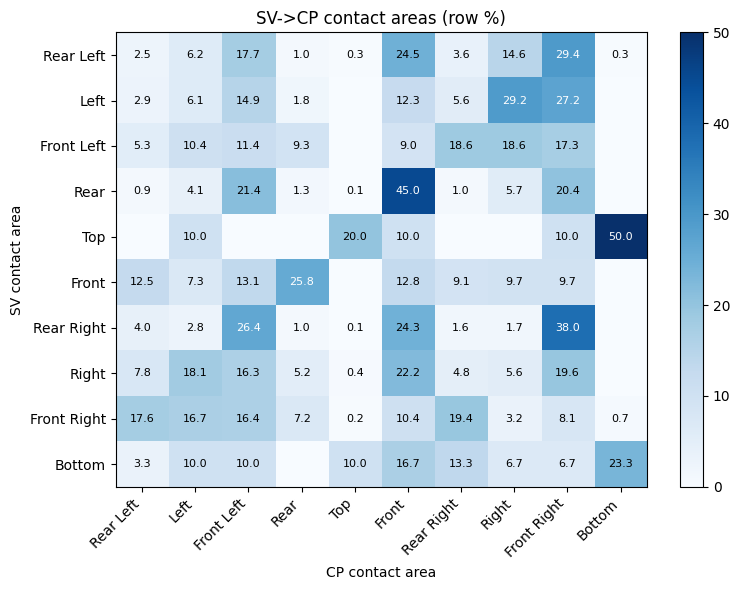

In [46]:
# %% heatmap visualization
import matplotlib.pyplot as plt  # noqa: E402
ex.plot_contact_area_pair_heatmap(ads_df, include_unknown=False, normalize='rows',
                                  title='SV->CP contact areas (row %)')
plt.show()


In [44]:

# %% subset: same function works on an arbitrary slice
waymo = ads_df[ads_df['Reporting Entity'].str.contains('Waymo', na=False)]
ex.contact_area_pairs(waymo).head(10)


,sv_area,cp_area,count,pct_of_rows,pct_of_pairs
0,Rear,Front,298,15.07,9.67
1,Rear Right,Front Right,254,12.84,8.24
2,Rear Left,Front Right,169,8.54,5.48
3,Rear,Front Left,147,7.43,4.77
4,Rear Left,Front,147,7.43,4.77
5,Rear Left,Right,143,7.23,4.64
6,Rear Right,Front Left,131,6.62,4.25
7,Rear,Front Right,122,6.17,3.96
8,Rear Left,Front Left,112,5.66,3.63
9,Rear Right,Front,110,5.56,3.57


In [45]:

# %% subset: only injury rows
injury = ads_df[ads_df['Highest Injury Severity Alleged'].notna()
            & (ads_df['Highest Injury Severity Alleged'].str.lower() != 'no injuries reported')]
print('injury rows:', injury.shape)
ex.contact_area_pairs(injury).head(10)

injury rows: (1196, 164)


,sv_area,cp_area,count,pct_of_rows,pct_of_pairs
0,Rear Right,Front Right,261,21.82,11.92
1,Rear,Front,155,12.96,7.08
2,Rear,Front Left,130,10.87,5.94
3,Rear Left,Front,123,10.28,5.62
4,Rear Left,Front Right,102,8.53,4.66
5,Rear,Front Right,99,8.28,4.52
6,Rear Right,Front,95,7.94,4.34
7,Rear Right,Front Left,86,7.19,3.93
8,Rear Left,Front Left,75,6.27,3.42
9,Rear,Right,65,5.43,2.97


### Notes
* wow this is kind of nuts. run this again when subset the data. Like it's all the back of the SV hitting the CP and since the SV is goign slow, it's like a bunch of getting rear ended.
* when subset a bit more intelligently run this again and see some intersting subsets
* also do with more rough ares (front, right side)
* like the heatmap, will want to do this again

## Testing treatment

In [47]:
df = ads_df.copy()

In [49]:

# %% straight normalizers (no fuzzy matching, just deterministic cleanup)
state_clean = ex.apply_normalizer(df['State'], ex.normalize_state)
print('State unique  :', df['State'].nunique(dropna=False),
      '->', state_clean.nunique(dropna=False))

display(df['State'].value_counts())
display(state_clean.value_counts())




State unique  : 31 -> 21


State
CA     1457
CA      459
AZ      421
TX      219
TX      143
AZ      136
NV       72
FL       42
GA       37
NV       21
GA       15
FL       15
MI       14
DC        9
MN        6
NM        6
CO        6
RI        5
WA        4
IN        4
DC        4
OH        3
PA        3
WY        3
PA        3
OK        2
TN        2
MN        2
MS        1
CO        1
Name: count, dtype: int64

State
CA    1916
AZ     557
TX     362
NV      93
FL      57
GA      52
MI      14
DC      13
MN       8
CO       7
NM       6
PA       6
RI       5
WA       4
IN       4
OH       3
WY       3
OK       2
TN       2
MS       1
Name: count, dtype: int64

In [52]:
org_clean = ex.apply_normalizer(df['Operating Entity'], ex.normalize_org_name)
print('OpEnt unique  :', df['Operating Entity'].nunique(dropna=False),
      '->', org_clean.nunique(dropna=False))

display(df['Operating Entity'].value_counts().head(10))
display(org_clean.value_counts().head(10))


OpEnt unique  : 79 -> 41


Operating Entity
Waymo LLC                  2122
Cruise LLC                  395
Zoox                        140
Argo AI                      50
Motional                     39
May Mobility                 38
Aurora Operations, Inc.      35
Avride Inc.                  31
Waymo LLC.                   26
Tesla Inc                    18
Name: count, dtype: int64

Operating Entity
waymo                2164
cruise                408
zoox                  156
may mobility           50
argo ai                50
avride                 44
motional               39
aurora operations      36
beep                   19
tesla                  18
Name: count, dtype: int64

In [54]:
permit_clean = ex.apply_normalizer(df['State or Local Permit'], ex.normalize_org_name)
print('Permit unique :', df['State or Local Permit'].nunique(dropna=False),
      '->', permit_clean.nunique(dropna=False))

display(df['State or Local Permit'].value_counts().head(10))
display(permit_clean.value_counts().head(10))


Permit unique : 65 -> 27


State or Local Permit
CA DMV, CA PUC                636
ADOT                          271
CA                            165
CA DMV AVT Permit              39
DMV, CPUC                      32
NV DMV AVT Permit              29
CA DMV, CA PUC\t\t\t\t\t\t     29
CA PUC, CA DMV                 27
Nevada                         23
AZ DOT                         12
Name: count, dtype: int64

State or Local Permit
ca dmv ca puc        711
adot                 300
ca                   165
ca dmv avt permit     43
dmv cpuc              32
nv dmv avt permit     29
ca puc ca dmv         27
nevada                25
az dot                12
az                    12
Name: count, dtype: int64

In [55]:
# %% suggest a consolidation mapping (rapidfuzz under the hood)
sugg_make = ex.suggest_consolidation(
    df['Make'], score_cutoff=85, normalizer=ex.normalize_org_name,
)
sugg_make.head(30)


,canonical,member,member_count,score
0,2024,2024,1,100
1,Chevrolet,Chevrolet,11,100
2,Chrysler,Chrysler,28,100
3,Cruise,Cruise,396,100
4,Cruise,Crui9se,1,92
5,EQS,EQS,2,100
6,EZ10,EZ10,6,100
7,FREIGHTLINER,FREIGHTLINER,5,100
8,FREIGHTLINER,Freightliner,3,100
9,Ford,Ford,50,100


In [56]:

# %% turn suggestions into a mapping, then apply
mapping_make = ex.mapping_from_suggestions(sugg_make)
print('mapping size:', len(mapping_make))
make_clean = ex.apply_mapping(df['Make'], mapping_make)
ex.consolidation_diff(df['Make'], make_clean)



mapping size: 18


,unique_before,unique_after,na_before,na_after
0,54,36,3,3


In [58]:
# %% override with a hand-curated mapping (case-insensitive lookup)
manual = {
    'JAGUAR': 'Jaguar',
    'JLR': 'Jaguar',         # JLR == Jaguar Land Rover
    'TOYOTA': 'Toyota',
    'HYUNDAI': 'Hyundai',
    'TESLA': 'Tesla',
    'ZOOX': 'Zoox',
}
make_manual = ex.apply_mapping(df['Make'], manual,
                               normalizer=ex.normalize_org_name)
display(make_manual.value_counts(dropna=False).head(15))

display(df['Make'].value_counts().head(15))




Make
Jaguar           2106
Cruise            396
Toyota            177
Hyundai            97
Peterbilt          51
Ford               50
Zoox               29
Chrysler           28
Tesla              18
Lexus              17
Mercedes-Benz      12
Chevrolet          11
Nissan             10
Volkswagen         10
Navya               9
Name: count, dtype: int64

Make
Jaguar       1353
JAGUAR        689
Cruise        396
Toyota        146
JLR            64
Peterbilt      51
HYUNDAI        51
Ford           50
Hyundai        46
TOYOTA         31
Chrysler       28
TESLA          18
Lexus          17
ZOOX           17
Zoox           12
Name: count, dtype: int64

In [59]:
# %% Investigating Agency: usually want a higher cutoff and a top_k cap
sugg_agency = ex.suggest_consolidation(
    df['Investigating Agency'], score_cutoff=88, top_k=80,
    normalizer=ex.normalize_org_name,
)
# Look at non-trivial groups (>1 member)
grp_sizes = sugg_agency.groupby('canonical').size()
multi = grp_sizes[grp_sizes > 1].index
sugg_agency[sugg_agency['canonical'].isin(multi)]


,canonical,member,member_count,score
3,Arizona Department of Public Safety,Arizona Department of Public Safety,7,100
4,Arizona Department of Public Safety,Texas Department of Public Safety,2,90
5,Arizona Department of Public Safety,Department of Public Safety,1,100
6,Atlanta Police Department,Atlanta Police Department,12,100
7,Atlanta Police Department,Gahanna Police Department,3,88
8,Austin Police Department,Austin Police Department,31,100
9,Austin Police Department,Houston Police Department,12,89
10,Austin Police Department,Austin Community College Police Department,2,100
11,Beverly Hills Police Department,Beverly Hills Police Department,3,100
12,Beverly Hills Police Department,Beverly Hills Police,2,100


In [60]:
# %% combine Make + Model into one consolidated field
make_model = ex.combine_columns(df, ['Make', 'Model'],
                                normalizer=ex.normalize_org_name,
                                name='make_model')
make_model.value_counts(dropna=False).head(15)

make_model
jaguar | i pace         2042
cruise | av              393
toyota | highlander      126
hyundai | ioniq 5         82
jlr | i pace              64
toyota | sienna           35
peterbilt | 579           34
ford | escape             34
chrysler | pacifica       28
peterbilt | 579 epiq      19
tesla | model y           18
zoox | zoox               17
ford | fusion             16
lexus | rx450h            15
zoox | sedan              12
Name: count, dtype: int64

In [61]:
col = 'Operating Entity'

# step 1: light deterministic clean
clean = ex.apply_normalizer(df[col], ex.normalize_org_name)

# step 2: fuzzy-suggest the rest
sugg = ex.suggest_consolidation(clean, score_cutoff=88)

# step 3: turn into a mapping; eyeball before applying
auto_map = ex.mapping_from_suggestions(sugg)
print('auto mapping size:', len(auto_map))

# step 4: optionally splice in manual fixes that the LLM/fuzzy missed
manual_overrides = {
    # 'cruise': 'Cruise',
    # 'waymo': 'Waymo',
}
final_map = {**auto_map, **manual_overrides}

# step 5: apply
df['Operating Entity Clean'] = ex.apply_mapping(clean, final_map)
df['Operating Entity Clean'].value_counts(dropna=False).head(15)


auto mapping size: 5


Operating Entity Clean
waymo                2165
cruise                408
zoox                  156
may mobility           50
argo ai                50
avride                 44
motional               40
aurora operations      36
beep                   19
tesla                  18
kodiak robotics        17
NaN                    17
pony ai                13
weride                 12
nuro                   12
Name: count, dtype: int64

In [62]:
df = ads_df.copy()
df = ex.add_master_entity(df, fuzzy=False, score_cutoff=92)

df['master_entity'].value_counts(dropna=False, normalize=True).head(50)

master_entity
Waymo                                                   0.693590
Cruise                                                  0.130769
Zoox                                                    0.050000
MAY Mobility                                            0.016026
Argo AI                                                 0.016026
Avride                                                  0.014423
Motional                                                0.012500
Aurora Operations                                       0.011538
Beep                                                    0.006090
Tesla                                                   0.005769
Kodiak Robotics                                         0.005449
Pony AI                                                 0.004167
Weride                                                  0.003846
Nuro                                                    0.003846
Admt Vwgoa                                              0.002564
Torc Roboti

In [63]:
df['master_entity'].value_counts().head(200)

master_entity
Waymo                                                   2164
Cruise                                                   408
Zoox                                                     156
MAY Mobility                                              50
Argo AI                                                   50
Avride                                                    45
Motional                                                  39
Aurora Operations                                         36
Beep                                                      19
Tesla                                                     18
Kodiak Robotics                                           17
Pony AI                                                   13
Weride                                                    12
Nuro                                                      12
Admt Vwgoa                                                 8
Torc Robotics                                              8
Colorado S

In [65]:
temp_list = df['master_entity'].drop_duplicates().to_list()
temp_list.sort()
temp_list

['5th Generation ADS',
 'Admt Vwgoa',
 'Apollo Autonomous Driving USA',
 'Apple',
 'Argo AI',
 'Aurora Operations',
 'Autox Technologies',
 'Avride',
 'Beep',
 'Chrysler (fca US Llc)',
 'Colorado School of Mines',
 'Cruise',
 'First Transit',
 'Ford Motor',
 'Ghost Autonomy',
 'Hyundai Motor America',
 'Internal Employee',
 'KIA America',
 'Kodiak Robotics',
 'Lucid USA',
 'MAY Mobility',
 'Mbus',
 'Mercedes Benz',
 'Mercedes Benz RD NA',
 'Mercedes Benz Research and Development NA',
 'Mercedes Benz Research and Development North America',
 'Motional',
 'Motional AD',
 'Navistar',
 'Navya',
 'Nuro',
 'Nvidia',
 'Ohmio',
 'Plusai',
 'Polestar',
 'Pony AI',
 'Robotic Research',
 'Stack AV',
 'Tesla',
 'Torc Robotics',
 'Tusimple',
 'Vinfast Auto',
 'Vislab SRL (subsidiary of Ambarella INC )',
 'Vwgoa Admt',
 'Waymo',
 'Waymo Lllc',
 'Weride',
 'Zoox']

### Notes
* cleaning generally works, will want to re-run some key things with the clean data
* the cleaned version of the data

* state or local permit can likely be turned into entities and then tallied. maybe web research. bit rough here
    * by hand probably simpler but maybe coudl go to agent for something to show off

## Scrap

In [19]:
ads_df['Narrative - CBI?'].value_counts(dropna=False)

Narrative - CBI?
     2810
Y     310
Name: count, dtype: int64